<a href="https://colab.research.google.com/github/mejia080902-bit/simulacion_II/blob/main/Metropolis_Hasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# -----------------------------------------
# Metropolis–Hastings 2D (objetivo no normalizado)
# Autor: Mejia Cedillo Diego
# Curso: Simulación II
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (activa proyecciones 3D)
import time

# Para reproducibilidad
SEED = 10000
rng = np.random.default_rng(SEED)

def soft_fmt(x, nd=6):
    return f"{x:.{nd}f}"


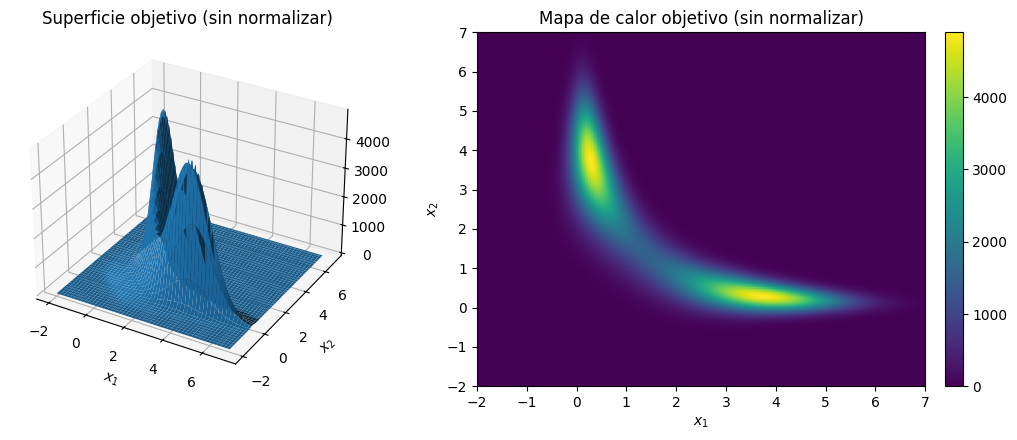

In [6]:
# -----------------------------------------
# Objetivo sin normalizar y su log
# f(x1,x2) ∝ exp( -[ x1^2 x2^2 + x1^2 + x2^2 - 8 x1 - 8 x2 ] / 2 )
# -----------------------------------------
def U(x1, x2):
    """Exponente positivo (sin el signo): (x1^2 x2^2 + x1^2 + x2^2 - 8 x1 - 8 x2)/2"""
    return 0.5 * (x1**2 * x2**2 + x1**2 + x2**2 - 8.0*x1 - 8.0*x2)

def logf(x):
    """Log-densidad sin normalizar: log f(x) = -U(x1,x2)"""
    x1, x2 = x
    return -U(x1, x2)

def f_unnorm(x1, x2):
    """Densidad sin normalizar (para graficar)"""
    return np.exp(-U(x1, x2))

# --- Gráfica objetivo (b): superficie y mapa de calor
x1_grid = np.linspace(-2.0, 7.0, 150)
x2_grid = np.linspace(-2.0, 7.0, 150)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = f_unnorm(X1, X2)

fig = plt.figure(figsize=(11,4.5))

ax = fig.add_subplot(1,2,1, projection='3d')
ax.plot_surface(X1, X2, Z, linewidth=0, antialiased=True)
ax.set_title("Superficie objetivo (sin normalizar)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax2 = fig.add_subplot(1,2,2)
hm = ax2.imshow(Z, origin='lower', extent=[x1_grid.min(), x1_grid.max(),
                                           x2_grid.min(), x2_grid.max()],
                aspect='auto')
ax2.set_title("Mapa de calor objetivo (sin normalizar)")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
plt.colorbar(hm, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [7]:
# -----------------------------------------
# Metropolis–Hastings con propuesta RW normal:
# x' = x + N(0, Sigma), Sigma = diag(s1^2, s2^2)
# Como q es simétrica: alpha = min(1, exp(logf(x') - logf(x)))
# -----------------------------------------
def mh_sample(log_pdf, x0, n_samples, proposal_scales=(0.7, 0.7), burnin=1000, thinning=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    s1, s2 = proposal_scales

    x = np.array(x0, dtype=float)
    logfx = log_pdf(x)
    chain = []
    accepts = 0
    total = 0

    t0 = time.time()
    for t in range(n_samples * thinning + burnin):
        # Propuesta simétrica (RW normal)
        proposal = x + rng.normal(loc=0.0, scale=[s1, s2], size=2)
        logf_prop = log_pdf(proposal)

        # (d) Probabilidad de aceptación
        log_alpha = logf_prop - logfx
        if np.log(rng.uniform()) < log_alpha:
            x = proposal
            logfx = logf_prop
            accepts += 1
        total += 1

        # Guardado tras burn-in y con thinning
        if t >= burnin and ((t - burnin) % thinning == 0):
            chain.append(x.copy())

    elapsed = time.time() - t0
    chain = np.array(chain)
    acc_rate = accepts / total
    return chain, acc_rate, elapsed


---- Resumen ejecución ----
muestra guardada       : 25000
razón de aceptación (d): 36.91 %
tiempo (s)             : 3.994

---- Maximización por muestreo (f) ----
punto MAP aprox = (3.7406, 0.2657)
log f(MAP)      = 8.499962


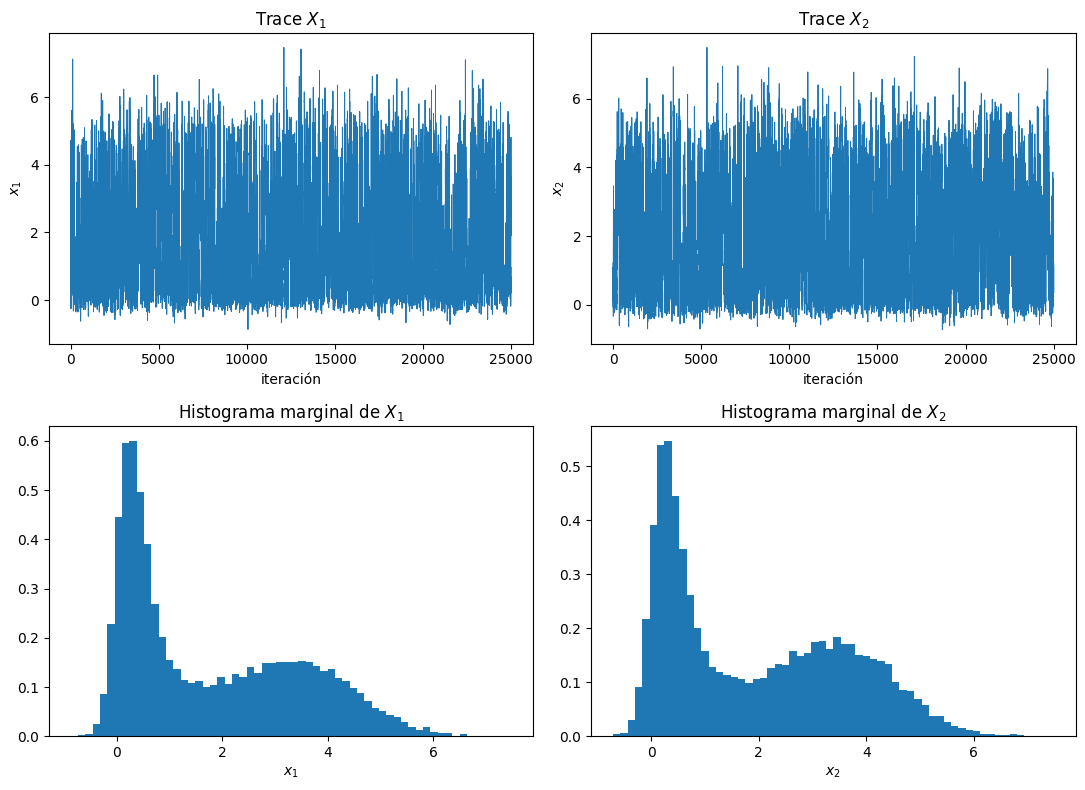

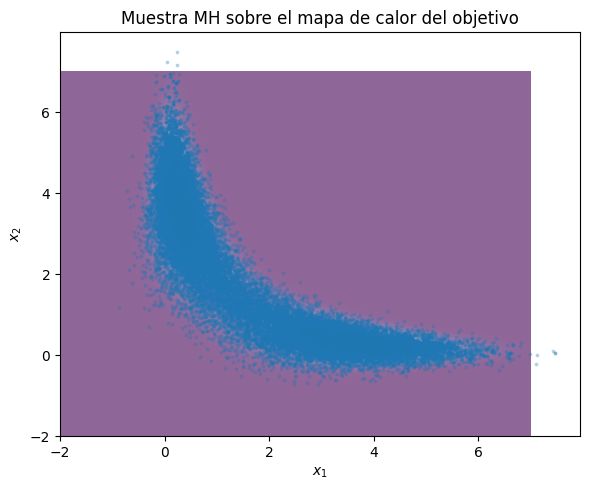

In [4]:
# -----------------------------------------
# Ejecutar MH
# -----------------------------------------
N = 25_000          # tamaño de muestra objetivo (post burn-in)
BURNIN = 2_500
THIN = 5            # útil para reducir autocorrelación efectiva
SCALES = (0.8, 0.8) # ajustar si la razón de aceptación sale muy baja/alta
x0 = np.array([0.0, 0.0])

chain, acc_rate, elapsed = mh_sample(logf, x0, N, proposal_scales=SCALES,
                                     burnin=BURNIN, thinning=THIN, rng=rng)

print("---- Resumen ejecución ----")
print(f"muestra guardada       : {len(chain)}")
print(f"razón de aceptación (d): {soft_fmt(acc_rate*100,2)} %")
print(f"tiempo (s)             : {soft_fmt(elapsed,3)}")

# (f) Maximización aproximada (MAP sobre la muestra)
log_vals = np.apply_along_axis(logf, 1, chain)
imax = np.argmax(log_vals)
x_map = chain[imax]
print("\n---- Maximización por muestreo (f) ----")
print(f"punto MAP aprox = ({soft_fmt(x_map[0],4)}, {soft_fmt(x_map[1],4)})")
print(f"log f(MAP)      = {soft_fmt(log_vals[imax],6)}")

# -----------------------------------------
# (e) Diagnóstico gráfico
# -----------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11,8))

# Trace plots
axes[0,0].plot(chain[:,0], lw=0.7)
axes[0,0].set_title("Trace $X_1$")
axes[0,0].set_xlabel("iteración")
axes[0,0].set_ylabel("$x_1$")

axes[0,1].plot(chain[:,1], lw=0.7)
axes[0,1].set_title("Trace $X_2$")
axes[0,1].set_xlabel("iteración")
axes[0,1].set_ylabel("$x_2$")

# Histogramas marginales
axes[1,0].hist(chain[:,0], bins=60, density=True)
axes[1,0].set_title("Histograma marginal de $X_1$")
axes[1,0].set_xlabel("$x_1$")

axes[1,1].hist(chain[:,1], bins=60, density=True)
axes[1,1].set_title("Histograma marginal de $X_2$")
axes[1,1].set_xlabel("$x_2$")

plt.tight_layout()
plt.show()

# Scatter sobre mapa de calor del objetivo (e)
fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(Z, origin='lower', extent=[x1_grid.min(), x1_grid.max(),
                                     x2_grid.min(), x2_grid.max()],
          aspect='auto', alpha=0.6)
ax.scatter(chain[:,0], chain[:,1], s=3, alpha=0.25)
ax.set_title("Muestra MH sobre el mapa de calor del objetivo")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.tight_layout()
plt.show()
